In [ ]:
import copy

import numpy as np
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import pandas as pd

In [11]:
data = pd.read_csv("data/data_preprocessed.csv")
data.head()

,Release_Period,Whether_Remake,Whether_Franchise,Lead_Star,Director,Music_Director,Number_of_Screens,Revenue(INR),Budget(INR),Genre_action,Genre_comedy,Genre_drama,Genre_love_story,Genre_other,Genre_thriller
0,1,0,0,1,1,1,5,5000000,85000,0,0,0,0,1,0
1,0,0,0,0,1,0,75,15000000,825000,0,0,1,0,0,0
2,0,0,0,1,1,1,525,75000000,56700000,0,0,0,0,0,1
3,0,0,0,0,1,1,800,210000000,4500000,0,0,1,0,0,0
4,0,0,0,0,0,0,1,1000000,1075000,0,0,0,0,1,0


In [12]:
target = data["Whether_Remake"]
features = data.drop(columns=["Whether_Remake"])

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2)

In [13]:
features = {
    "train": features_train,
    "test": features_test
}

target = {
    "train": target_train,
    "test": target_test
}

In [14]:
features_dropped = copy.deepcopy(features)
target_dropped = copy.deepcopy(target)
continuous_columns = ["Number_of_Screens", "Budget(INR)", "Revenue(INR)"]

for column in continuous_columns:
    q = features["train"][column].quantile(0.95)
    drop_mask = features_dropped["train"][column] < q

    features_dropped = {
        "train": features_dropped["train"][drop_mask],
        "test": features_dropped["test"]
    }

    target_dropped = {
        "train": target_dropped["train"][drop_mask],
        "test": target_dropped["test"]
    }

features_dropped["train"].shape

(1250, 14)

In [15]:
feature_scaler = MinMaxScaler()
features_scaled = {
    "train": pd.DataFrame(feature_scaler.fit_transform(features_dropped["train"]), columns=features_dropped["train"].columns),
    "test": pd.DataFrame(feature_scaler.transform(features_dropped['test']), columns=features_dropped["train"].columns)
}

target_scaler = MinMaxScaler()
target_scaled = {
    "train": target_scaler.fit_transform(target_dropped["train"].to_numpy().reshape(-1, 1)),
    "test": target_scaler.transform(target_dropped["test"].to_numpy().reshape(-1, 1))
}

features_scaled["train"]

,Release_Period,Whether_Franchise,Lead_Star,Director,Music_Director,Number_of_Screens,Revenue(INR),Budget(INR),Genre_action,Genre_comedy,Genre_drama,Genre_love_story,Genre_other,Genre_thriller
0,1.0,0.0,0.0,0.0,1.0,0.906933,0.684030,0.593812,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.006515,0.015228,0.000450,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.034435,0.069645,0.000679,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,1.0,1.0,0.418334,0.385615,0.292201,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,1.0,0.255468,0.104753,0.022667,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,0.0,0.0,0.0,0.0,0.0,0.000000,0.002940,0.000026,0.0,0.0,1.0,0.0,0.0,0.0
1246,1.0,0.0,0.0,0.0,1.0,0.013495,0.030149,0.000473,0.0,0.0,0.0,1.0,0.0,0.0
1247,0.0,0.0,0.0,0.0,0.0,0.004188,0.010840,0.000565,1.0,0.0,0.0,0.0,0.0,0.0
1248,1.0,0.0,0.0,0.0,0.0,0.008841,0.016983,0.000199,0.0,0.0,0.0,1.0,0.0,0.0


In [16]:
model_types = ["Random forest", "SVM", "MLP"]

algorithm_parameters = {
    "Random forest": {
        "n_estimators": range(10, 310, 20),
        "max_depth": [5, 10, 50, 100, None],
        "min_samples_split": [2, 3, 5, 10, 50]
    },
    "SVM":{
        "kernel": ("linear", "poly", "rbf", "sigmoid"),
        "degree": range(3, 6),
        "gamma": ("scale", "auto")
    },
    "MLP":{
        "activation": ("identity", "logistic", "tanh", "relu"),
        "solver": ("lbfgs", "sgd", "adam"),

    }
}

predictions = {model_type: np.empty(0) for model_type in model_types}

In [17]:
svm = SVC()
svm_clf = GridSearchCV(svm, algorithm_parameters["SVM"])

svm_clf.fit(features_scaled["train"], target_scaled["train"].ravel())
predictions["SVM"] = svm_clf.predict(features_scaled["test"]).reshape(-1, 1)

In [18]:
random_forest = RandomForestClassifier()
random_forest_clf = GridSearchCV(random_forest, algorithm_parameters["Random forest"])

random_forest_clf.fit(features_scaled["train"], target_scaled["train"].ravel())
predictions["Random forest"] = random_forest_clf.predict(features_scaled["test"]).reshape(-1, 1)

In [19]:
mlp = MLPClassifier()
mlp_clf = GridSearchCV(mlp, algorithm_parameters["MLP"])

mlp_clf.fit(features_scaled["train"], target_scaled["train"].ravel())
predictions["MLP"] = mlp_clf.predict(features_scaled["test"]).reshape(-1, 1)

/home/a.yasinetski/Study/bollywood/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/a.yasinetski/Study/bollywood/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/a.yasinetski/Study/bollywood/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/a.yasinetski/Study/bollywood/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.



In [21]:
for model_type in model_types:
    print(model_type)
    print(classification_report(target_scaled["test"], predictions[model_type]))

Random forest
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97       322
         1.0       0.00      0.00      0.00        18

    accuracy                           0.94       340
   macro avg       0.47      0.50      0.49       340
weighted avg       0.90      0.94      0.92       340

SVM
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97       322
         1.0       0.00      0.00      0.00        18

    accuracy                           0.95       340
   macro avg       0.47      0.50      0.49       340
weighted avg       0.90      0.95      0.92       340

MLP
              precision    recall  f1-score   support

         0.0       0.96      0.95      0.95       322
         1.0       0.19      0.22      0.21        18

    accuracy                           0.91       340
   macro avg       0.57      0.58      0.58       340
weighted avg       0.92      0.91      0.91       34

/home/a.yasinetski/Study/bollywood/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/a.yasinetski/Study/bollywood/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/a.yasinetski/Study/bollywood/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

Random forest
SVM
MLP


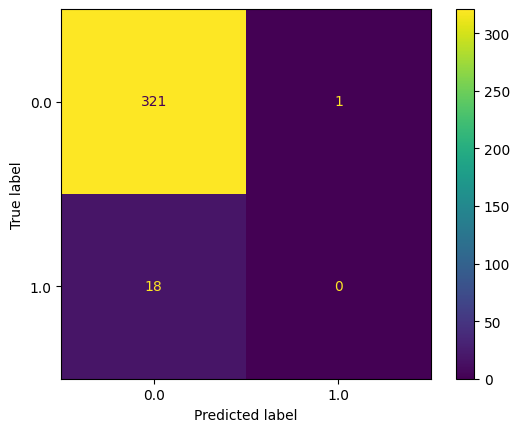

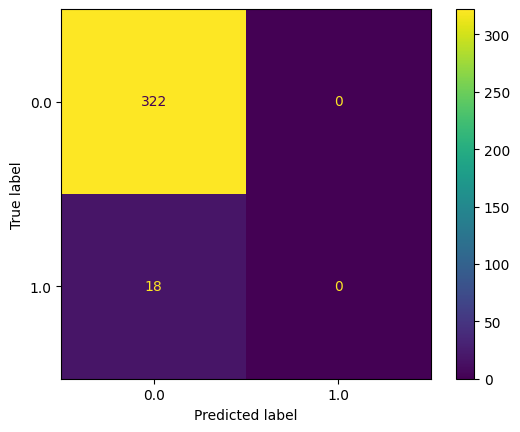

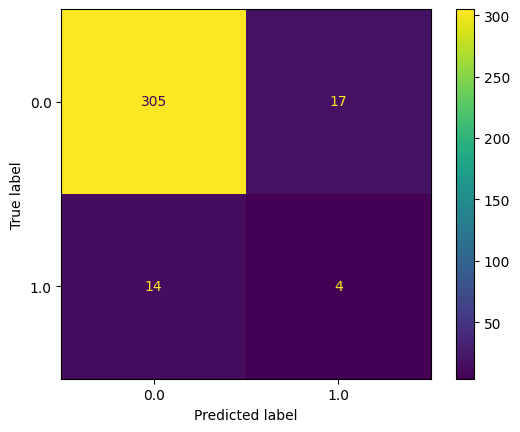

In [24]:
for model_type in model_types:
    print(model_type)
    ConfusionMatrixDisplay.from_predictions(target_scaled["test"], predictions[model_type])